# Feature Engineering - US Traffic Incident Analysis
ขั้นตอนนี้เป็นการสร้างและคัดเลือก Features ที่จำเป็น โดยรวบรวมเทคนิคที่ดีที่สุดจากทีมงานและอ้างอิงจากผลการวิเคราะห์ EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')
import sys

sys.path.append('../src')

import util as ut

In [2]:
# Load data
df_train_feature = pd.read_csv("../data/processed/01.3/train_advance_clean.csv")
df_test_feature = pd.read_csv("../data/processed/01.3/test_advance_clean.csv")

print(f"Train shape: {df_train_feature.shape}")
print(f"Test shape: {df_test_feature.shape}")

Train shape: (5469092, 40)
Test shape: (1367273, 38)


## 1. Feature Engineering

In [3]:
print("Applying feature engineering pipeline...")
df_train_feature = ut.feature_engineering_pipeline(df_train_feature)
df_test_feature = ut.feature_engineering_pipeline(df_test_feature)

print(f"New Train shape: {df_train_feature.shape}")
print(f"New Test shape: {df_test_feature.shape}")

Applying feature engineering pipeline...
New Train shape: (5469092, 62)
New Test shape: (1367273, 60)


## 2. Skewness and Transformation

In [4]:
print("Skewness check before transformation:")
ut.skewed(df_train_feature)

Skewness check before transformation:
[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.057  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.482  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +3.757  →  highly skewed right (positive)
[MODERATE]   Temperature(F)                 skew = -0.507  →  moderately skewed left (negative)
[MODERATE]   Wind_Chill(F)                  skew = -0.730  →  moderately skewed left (negative)
[NORMAL]     Humidity(%)                    skew = -0.406  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.832  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = -2.469  →  highly skewed left (negative)
[MODERATE]   Wind_Speed(mph)                skew = +0.628  →  moderately skewed right (positive)
[SKEWED]     Precipitation(in)              s

In [5]:
print("Applying automatic skewness transformation...")
df_train_feature = ut.auto_transform_skewness(df_train_feature)
df_test_feature = ut.auto_transform_skewness(df_test_feature)

print("\nSkewness check after transformation:")
ut.skewed(df_train_feature)

Applying automatic skewness transformation...

Skewness check after transformation:
[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.057  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.482  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +2.218  →  highly skewed right (positive)
[NORMAL]     Temperature(F)                 skew = +0.247  →  approximately symmetric
[NORMAL]     Wind_Chill(F)                  skew = +0.140  →  approximately symmetric
[NORMAL]     Humidity(%)                    skew = -0.406  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.466  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = -2.074  →  highly skewed left (negative)
[MODERATE]   Wind_Speed(mph)                skew = -0.814  →  moderately skewed left (negative)
[SKEWED]     Precipi

### 2.1 Comparison: Distribution Before vs After Transformation
เปรียบเทียบการกระจายตัวของตัวแปรหลัก (Original Features) เพื่อดูผลลัพธ์ของการทำ Skewness Correction (Log/Sqrt)

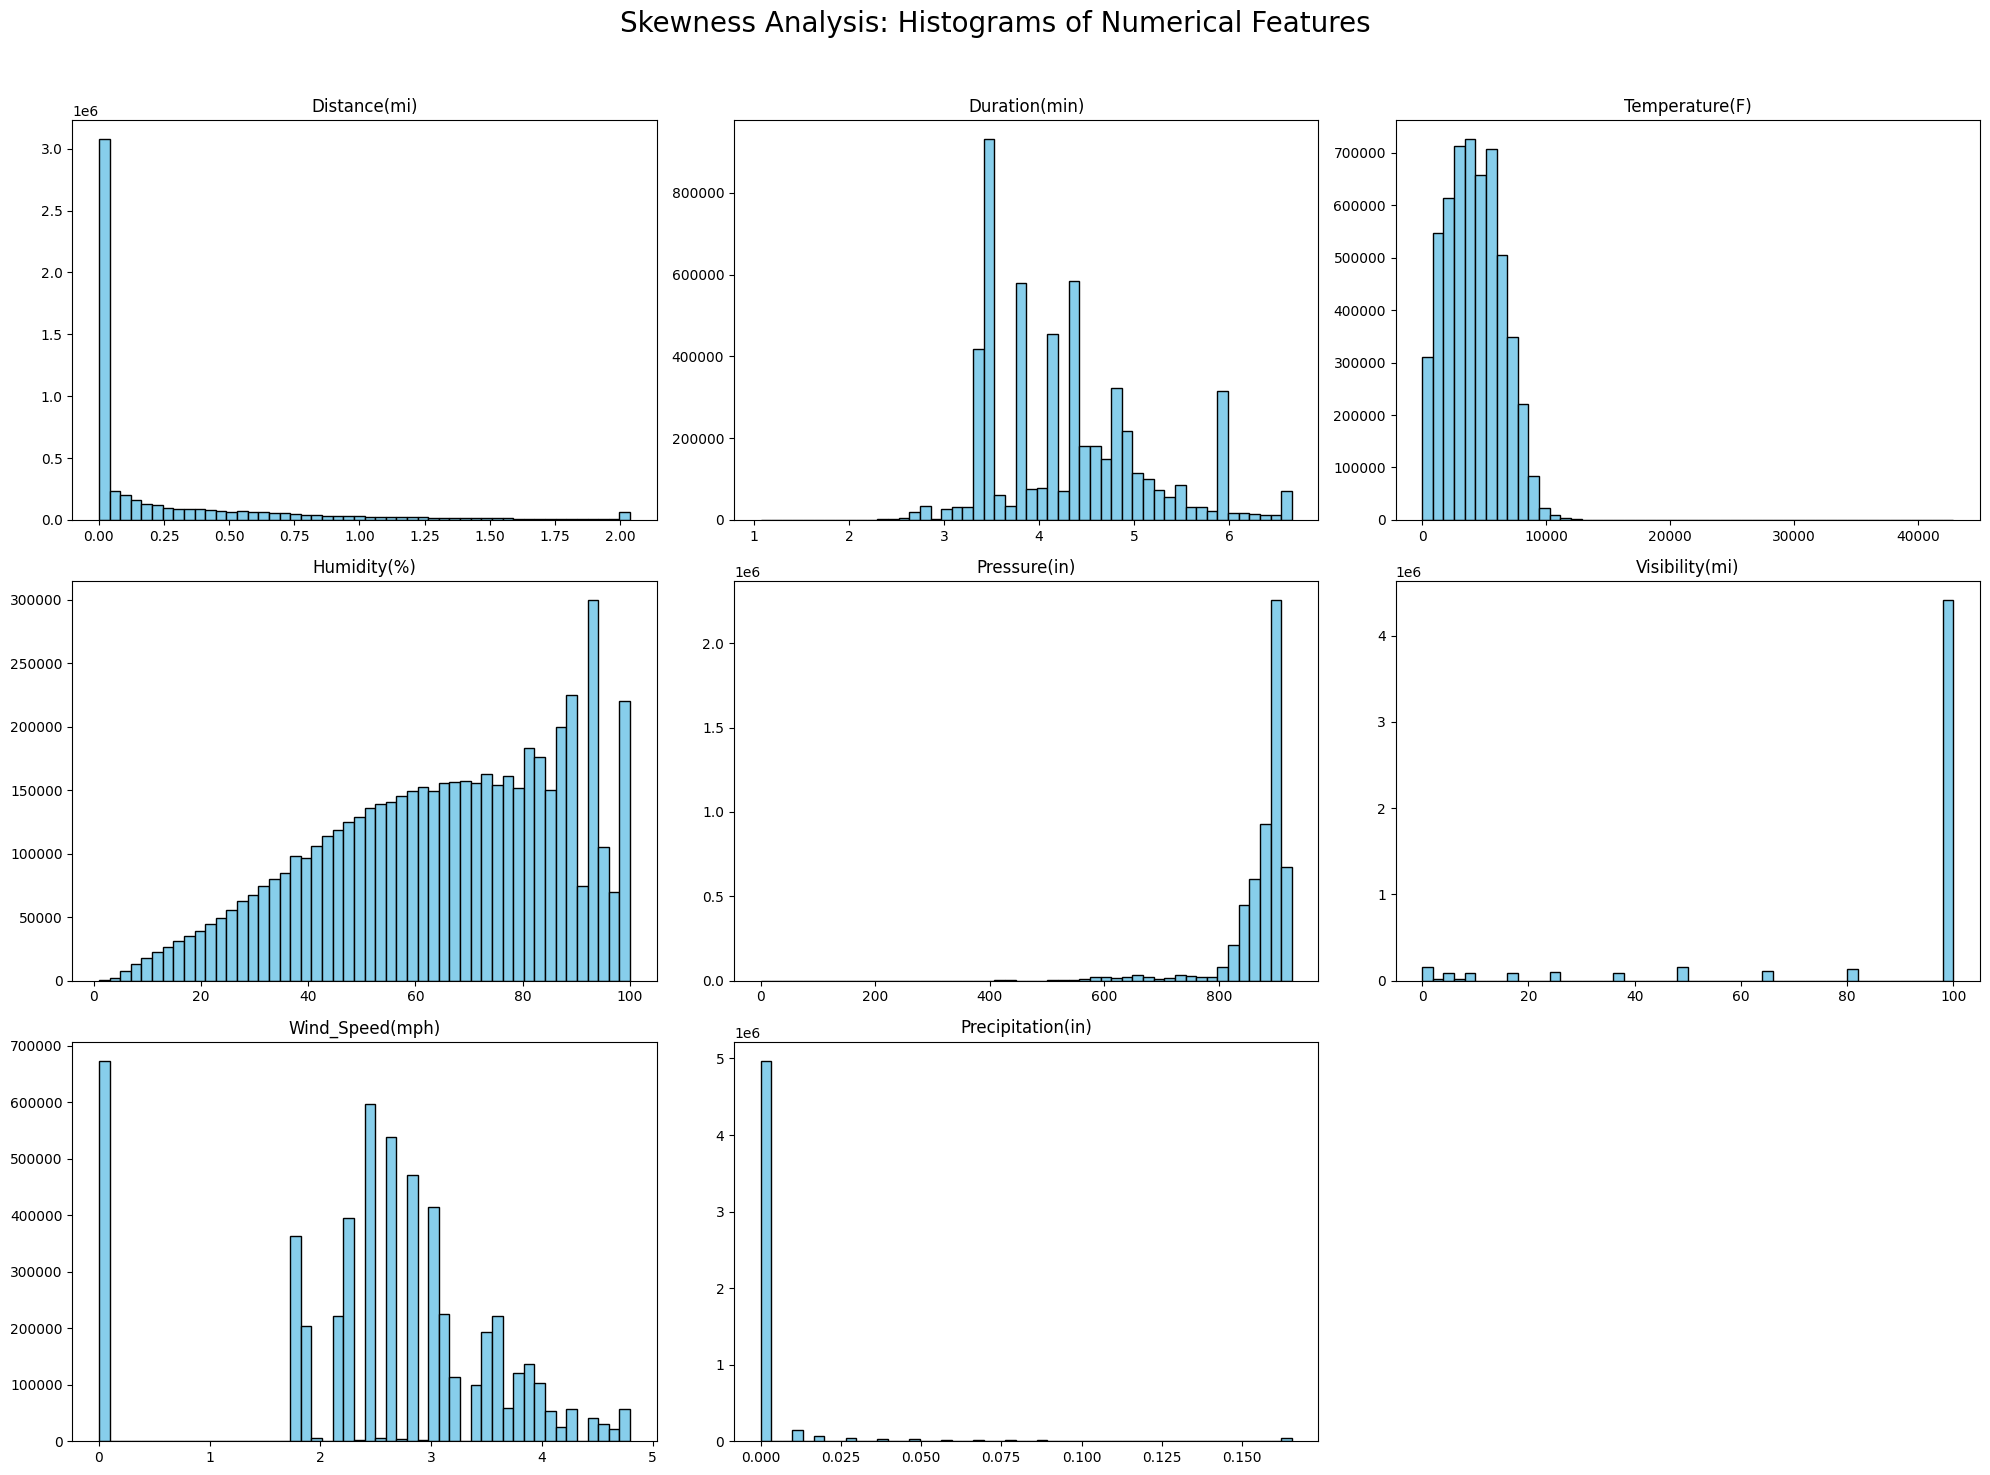

--- Skewness Values ---
Precipitation(in)    5.807073
Distance(mi)         2.217652
Duration(min)        0.681560
Temperature(F)       0.246676
Humidity(%)         -0.406073
Wind_Speed(mph)     -0.814006
Visibility(mi)      -2.073518
Pressure(in)        -3.465858
dtype: float64

--- Features suggested for Log Transformation (Skewness > 1 or < -1) ---
['Precipitation(in)', 'Distance(mi)', 'Visibility(mi)', 'Pressure(in)']


In [6]:
# เลือกเฉพาะตัวแปรดั้งเดิม (อ้างอิงจาก EDA)
original_num_cols = [
    'Distance(mi)', 'Duration(min)', 'Temperature(F)', 'Humidity(%)', 
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

# สร้าง Histograms สำหรับทุก Feature เพื่อดูการกระจายตัว
df_train_feature[original_num_cols].hist(bins=50, figsize=(20, 15), color='skyblue', edgecolor='black', grid=False)
plt.suptitle('Skewness Analysis: Histograms of Numerical Features', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# คำนวณค่า Skewness ประกอบการตัดสินใจ
print("--- Skewness Values ---")
skew_vals = df_train_feature[original_num_cols].skew().sort_values(ascending=False)
print(skew_vals)

print("\n--- Features suggested for Log Transformation (Skewness > 1 or < -1) ---")
print(skew_vals[(skew_vals > 1) | (skew_vals < -1)].index.tolist())

## 3. Data Optimization

In [7]:
def optimize_dtypes(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64':
            if df[col].min() >= 0 and df[col].max() < 255:
                df[col] = df[col].astype('uint8')
            else:
                df[col] = df[col].astype('int32')
    return df

print("Optimizing data types...")
df_train_feature = optimize_dtypes(df_train_feature)
df_test_feature = optimize_dtypes(df_test_feature)
gc.collect()

Optimizing data types...


44509

In [ ]:
# # Save processed data
# import os
# os.makedirs("../data/processed/03", exist_ok=True)
# df_train_feature.to_csv("../data/processed/03/train_features.csv", index=False)
# df_test_feature.to_csv("../data/processed/03/test_features.csv", index=False)

# print("Data saved to data/processed/03/")